# AbruptInsects detector comparison inside STUDD

This notebook compares different drift detectors inside the STUDD mechanism on the AbruptInsects dataset.

AbruptInsects is a modified version of the Insects dataset where the stream is split into three segments and the middle segment is shuffled to introduce abrupt drift in the feature space.

Since the stream has 5325 instances and three segments, we use the segment boundaries as reference drift points:

- first drift: 1775
- second drift: 3550

For each detector, we record:

- all alarms produced by each detector
- whether each alarm matches a known drift within a fixed window
- detection delay for matched alarms
- teacher-student disagreement around each alarm
- teacher-student disagreement around the known true drift points

In [11]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from capymoa.stream import NumpyStream

from capymoa.drift.detectors import (
    STUDD,
    ADWIN,
    PageHinkley,
    HDDMAverage,
    HDDMWeighted,
    CUSUM,
)

from helpers import (
    configure_matplotlib,
    rolling_mean,
)

from studd_utils import (
    make_teacher,
    make_student,
)

configure_matplotlib()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load AbruptInsects data

The dataset is stored as a comma-separated `.data` file.

The last column is the class label and all previous columns are input features.

In [12]:
DATA_PATH = "data/AbruptInsects.data"

df = pd.read_csv(
    DATA_PATH,
    header=None,
)

X = df.iloc[:, :-1].to_numpy(dtype=float)
y = df.iloc[:, -1].to_numpy(dtype=int)

print("Shape:", df.shape)
print("Class distribution:")
print(pd.Series(y).value_counts().sort_index())

Shape: (5325, 50)
Class distribution:
1     954
2     917
3    1265
4    1285
5     904
Name: count, dtype: int64


## Experimental parameters

The first known drift occurs at position 1775.

To allow STUDD monitoring before this drift, we use an initial training window smaller than the first segment.

The `MATCH_WINDOW` parameter controls whether a STUDD alarm is considered close enough to a known drift point.

If an alarm is farther than `MATCH_WINDOW` observations from all known drifts, it is treated as unmatched rather than being forced to match an unrelated drift.

In [13]:
SEED = 1

N_STREAM = 5325
W = 500

DRIFT_POINTS = [1775, 3550]

N_TREES = 100
PH_DELTA = 0.001

TEACHER_TYPE = "rf"
STUDENT_TYPE = "rf"

LOCAL_WINDOW = 100
ROLLING_WINDOW = 100

MATCH_WINDOW = 500

## Detectors

We compare the same five detectors used in the other detector-comparison notebooks.

Page-Hinkley is configured with `delta = 0.001`.

In [14]:
DETECTORS = {
    "ADWIN": lambda: ADWIN(),
    "PageHinkley": lambda: PageHinkley(delta=PH_DELTA),
    "HDDMAverage": lambda: HDDMAverage(),
    "HDDMWeighted": lambda: HDDMWeighted(),
    "CUSUM": lambda: CUSUM(),
}

## Run STUDD with each detector

For each detector, we recreate the same stream from the NumPy arrays.

The teacher is trained on the first `W` samples and then kept fixed.

The student learns online to mimic the teacher.

Only the drift detector inside STUDD changes.

In [15]:
comparison_runs = {}

for detector_name, detector_factory in DETECTORS.items():

    print(f"Running {detector_name}...")

    stream = NumpyStream(
        X,
        y,
        dataset_name="AbruptInsects",
    )

    schema = stream.get_schema()

    teacher = make_teacher(
        schema=schema,
        teacher_type=TEACHER_TYPE,
        seed=SEED,
        n_trees=N_TREES,
    )

    for _ in range(W):
        inst = stream.next_instance()
        teacher.train(inst)

    student = make_student(
        schema=schema,
        student_type=STUDENT_TYPE,
        seed=SEED,
        n_trees=N_TREES,
    )

    studd = STUDD(
        student=student,
        min_n_instances=W,
        detector=detector_factory(),
    )

    records = []
    studd_drift_points = []

    processed = W

    while stream.has_more_instances() and processed < N_STREAM:

        inst = stream.next_instance()

        y_true = inst.y_index
        y_teacher = teacher.predict(inst)

        if y_teacher is None:
            processed += 1
            continue

        y_student = student.predict(inst)

        if y_student is None:
            agreement = np.nan
            disagreement = np.nan
        else:
            agreement = int(y_student == y_teacher)
            disagreement = 1 - agreement

        teacher_correct = int(y_teacher == y_true)

        studd.add_element(
            inst,
            y_teacher,
        )

        detected_change = studd.detected_change()

        if detected_change:
            studd_drift_points.append(int(processed))

        records.append({
            "t": int(processed),
            "teacher_correct": teacher_correct,
            "agreement": agreement,
            "disagreement": disagreement,
            "drift_alarm": detected_change,
        })

        processed += 1

    results = pd.DataFrame(records)

    comparison_runs[detector_name] = {
        "results": results,
        "studd_drift_points": studd_drift_points,
    }

print("Done.")

Running ADWIN...
Running PageHinkley...
Running HDDMAverage...
Running HDDMWeighted...
Running CUSUM...
Done.


## Alarm-level comparison

Each row corresponds to one STUDD alarm.

According to the paper, an alarm is first checked as a possible early detection of a future drift. If it occurs at most `MATCH_WINDOW` observations before a known drift, it is matched to that future drift.

If the alarm is not close enough to any future drift, then it is treated as a delayed detection of the most recent past drift.

In [16]:
alarm_rows = []

sorted_drifts = sorted(DRIFT_POINTS)

for detector_name, run in comparison_runs.items():

    results = run["results"]

    for alarm in run["studd_drift_points"]:

        matched_drift = None
        detection_delay = np.nan

        # Priority 1: early detection of a future drift
        for drift_pos in sorted_drifts:
            if alarm < drift_pos and drift_pos - alarm <= MATCH_WINDOW:
                matched_drift = drift_pos
                detection_delay = alarm - drift_pos
                break

        # Priority 2: delayed detection of the most recent past drift
        if matched_drift is None:
            past_drifts = [
                drift_pos
                for drift_pos in sorted_drifts
                if drift_pos <= alarm
            ]

            if past_drifts:
                matched_drift = max(past_drifts)
                detection_delay = alarm - matched_drift

        before = results[
            (results["t"] >= alarm - LOCAL_WINDOW)
            &
            (results["t"] < alarm)
        ]["disagreement"].dropna()

        after = results[
            (results["t"] >= alarm)
            &
            (results["t"] < alarm + LOCAL_WINDOW)
        ]["disagreement"].dropna()

        before_mean = before.mean() if len(before) > 0 else np.nan
        after_mean = after.mean() if len(after) > 0 else np.nan

        disagreement_delta = (
            after_mean - before_mean
            if not np.isnan(before_mean) and not np.isnan(after_mean)
            else np.nan
        )

        alarm_rows.append({
            "detector": detector_name,
            "alarm": alarm,
            "matched_drift": matched_drift,
            "detection_delay": detection_delay,
            "disagreement_before_alarm": before_mean,
            "disagreement_after_alarm": after_mean,
            "disagreement_delta_alarm": disagreement_delta,
        })

alarm_df = pd.DataFrame(alarm_rows)

alarm_df = (
    alarm_df
    .sort_values(by=["detector", "alarm"])
    .reset_index(drop=True)
)

alarm_df

,detector,alarm,matched_drift,detection_delay,disagreement_before_alarm,disagreement_after_alarm,disagreement_delta_alarm
0,ADWIN,3843,3550,293,0.060000,0.100000,0.040000
1,ADWIN,4355,3550,805,0.040000,0.060000,0.020000
2,ADWIN,5251,3550,1701,0.020000,0.040541,0.020541
3,CUSUM,4255,3550,705,0.060000,0.040000,-0.020000
4,HDDMAverage,3268,3550,-282,0.089286,0.098039,0.008754
5,HDDMWeighted,3277,3550,-273,0.089286,0.115385,0.026099
6,PageHinkley,5204,3550,1654,0.020000,0.040000,0.020000


## Detector-level summary

This table shows the alarms found by each detector and how many of them are matched to known drift points.

In [17]:
summary_rows = []

for detector_name, run in comparison_runs.items():

    detector_alarm_df = alarm_df[
        alarm_df["detector"] == detector_name
    ]

    summary_rows.append({
        "detector": detector_name,
        "num_alarms": len(run["studd_drift_points"]),
        "alarms": run["studd_drift_points"],
        "matched_alarms": detector_alarm_df["matched_drift"].notna().sum(),
        "unmatched_alarms": detector_alarm_df["matched_drift"].isna().sum(),
    })

summary_df = pd.DataFrame(summary_rows)

summary_df

,detector,num_alarms,alarms,matched_alarms,unmatched_alarms
0,ADWIN,3,"[3843, 4355, 5251]",3,0
1,PageHinkley,1,[5204],1,0
2,HDDMAverage,1,[3268],1,0
3,HDDMWeighted,1,[3277],1,0
4,CUSUM,1,[4255],1,0


## Disagreement around true drift points

This table measures the teacher-student disagreement before and after each known drift point.

This is computed once using the disagreement signal from the first detector run, since the true drift locations are independent of the detector.

In [18]:
reference_detector = list(comparison_runs.keys())[0]
reference_results = comparison_runs[reference_detector]["results"]

true_drift_rows = []

for drift_pos in DRIFT_POINTS:

    before = reference_results[
        (reference_results["t"] >= drift_pos - LOCAL_WINDOW)
        &
        (reference_results["t"] < drift_pos)
    ]["disagreement"].dropna()

    after = reference_results[
        (reference_results["t"] >= drift_pos)
        &
        (reference_results["t"] < drift_pos + LOCAL_WINDOW)
    ]["disagreement"].dropna()

    before_mean = before.mean() if len(before) else np.nan
    after_mean = after.mean() if len(after) else np.nan

    true_drift_rows.append({
        "drift": drift_pos,
        "disagreement_before_drift": before_mean,
        "disagreement_after_drift": after_mean,
        "disagreement_delta_drift": (
            after_mean - before_mean
            if not np.isnan(before_mean) and not np.isnan(after_mean)
            else np.nan
        ),
    })

true_drift_disagreement_df = pd.DataFrame(true_drift_rows)

true_drift_disagreement_df

,drift,disagreement_before_drift,disagreement_after_drift,disagreement_delta_drift
0,1775,0.14000,0.327869,0.187869
1,3550,0.16129,0.080000,-0.081290


## Rolling teacher accuracy

Known drift points are shown in green.  
STUDD alarms are shown in red.

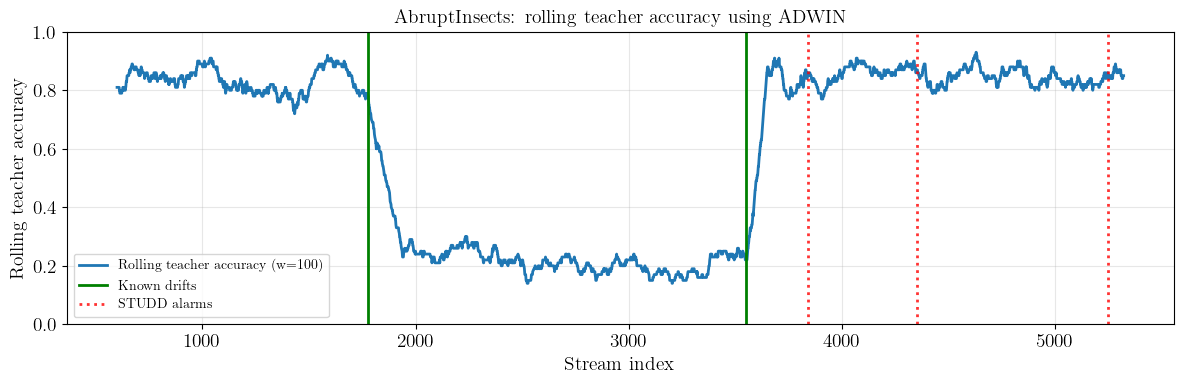

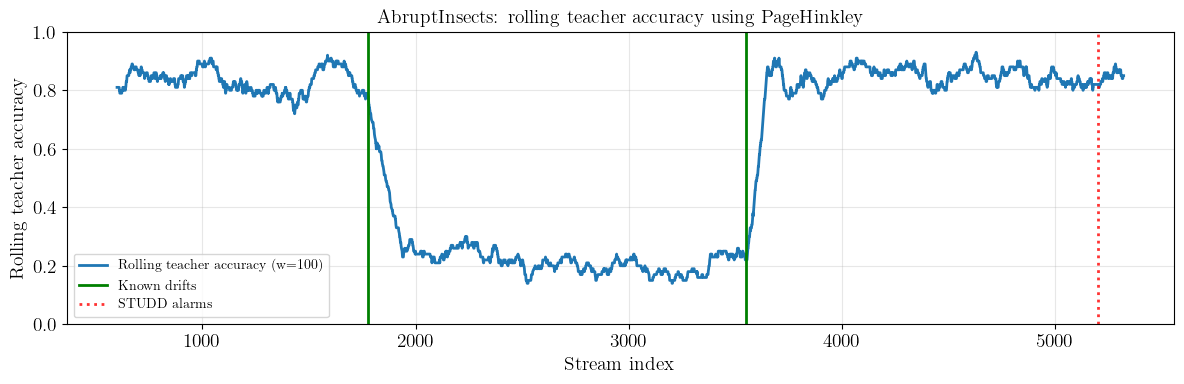

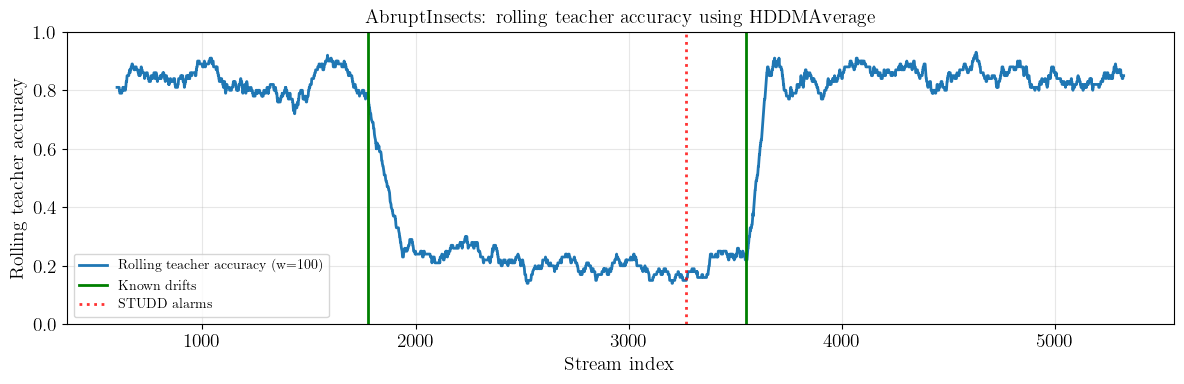

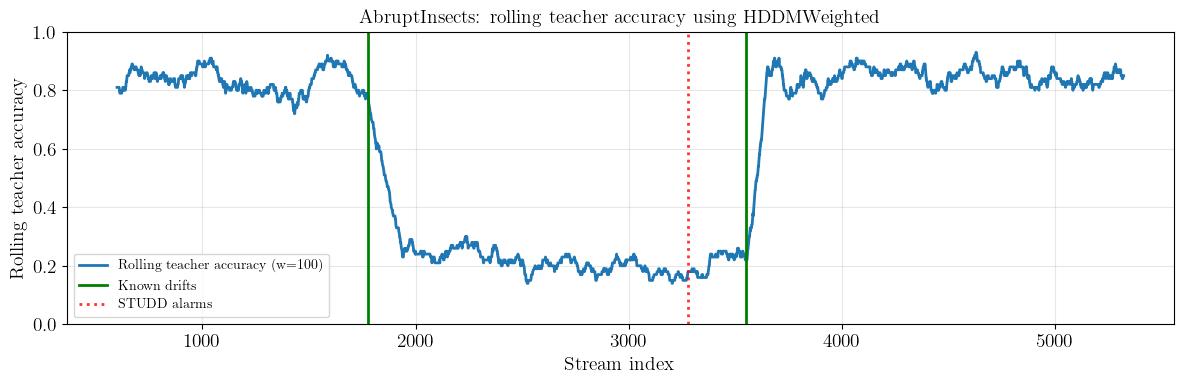

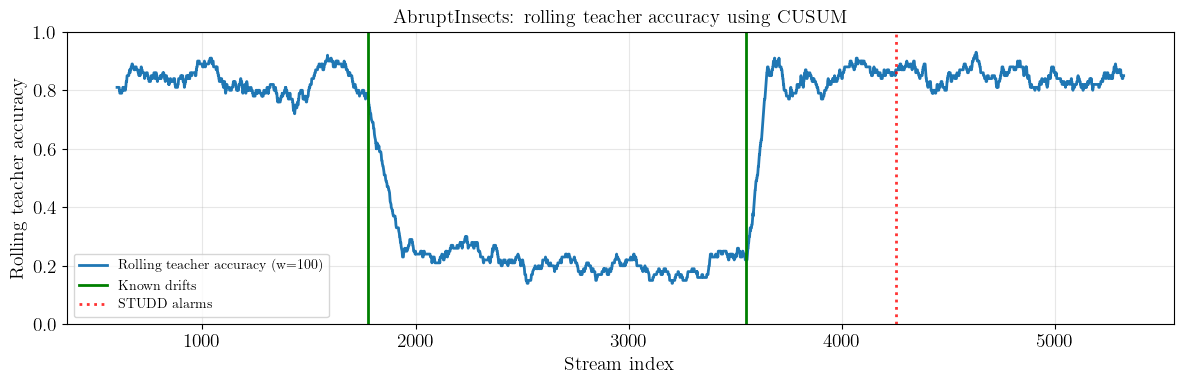

In [19]:
for detector_name, run in comparison_runs.items():

    results = run["results"]
    alarms = run["studd_drift_points"]

    rolling_accuracy, _ = rolling_mean(
        results["teacher_correct"].to_numpy(dtype=float),
        ROLLING_WINDOW,
    )

    rolling_t = results["t"].to_numpy()[
        ROLLING_WINDOW - 1:
    ]

    plt.figure(figsize=(12, 4))

    plt.plot(
        rolling_t,
        rolling_accuracy,
        linewidth=2,
        label=f"Rolling teacher accuracy (w={ROLLING_WINDOW})",
    )

    for i, drift_pos in enumerate(DRIFT_POINTS):
        plt.axvline(
            drift_pos,
            color="green",
            linewidth=2,
            label="Known drifts" if i == 0 else None,
        )

    for i, alarm in enumerate(alarms):
        plt.axvline(
            alarm,
            color="red",
            linestyle=":",
            linewidth=2,
            alpha=0.8,
            label="STUDD alarms" if i == 0 else None,
        )

    plt.title(f"AbruptInsects: rolling teacher accuracy using {detector_name}")
    plt.xlabel("Stream index")
    plt.ylabel("Rolling teacher accuracy")
    plt.ylim(0, 1)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Rolling teacher-student disagreement

This plot uses the disagreement signal explicitly recorded during monitoring.

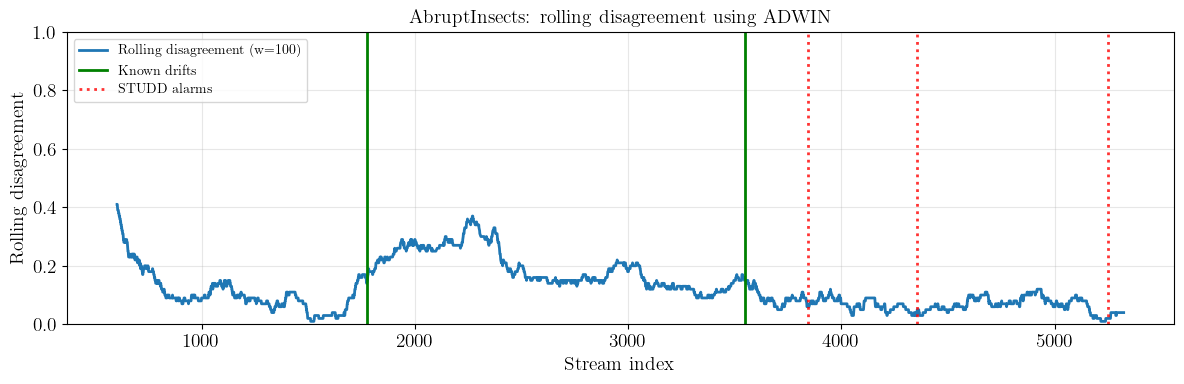

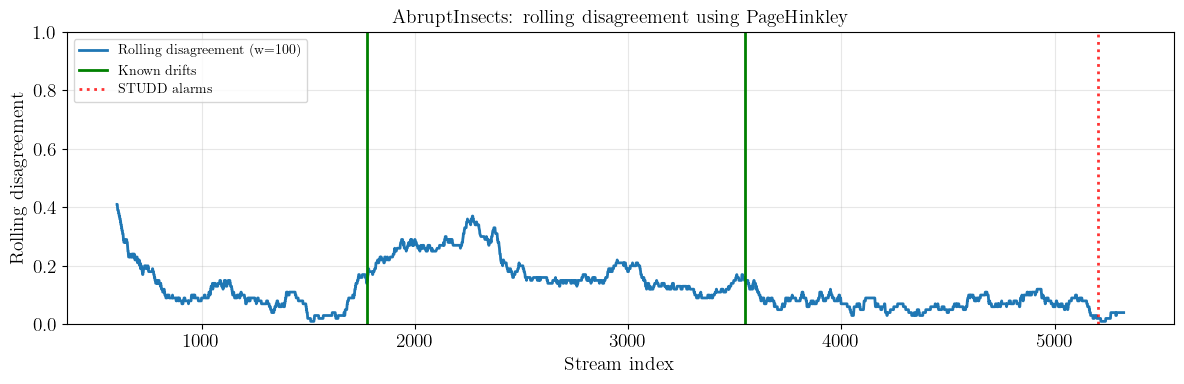

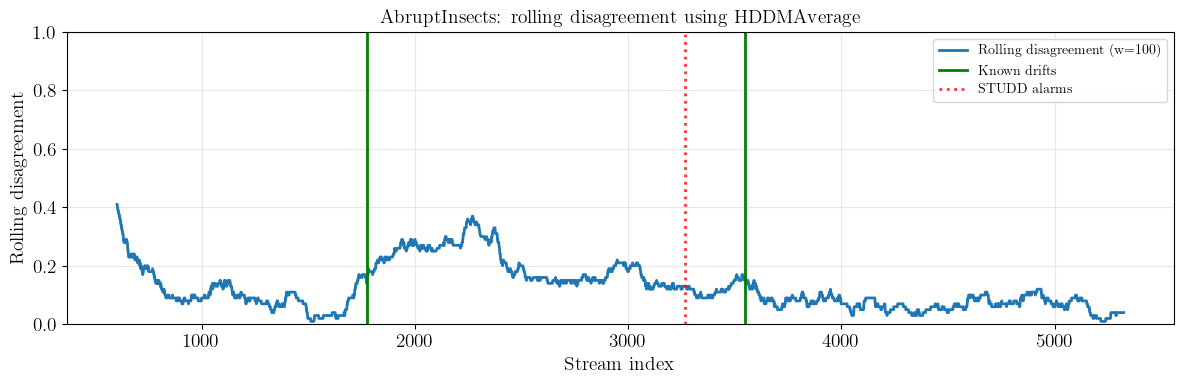

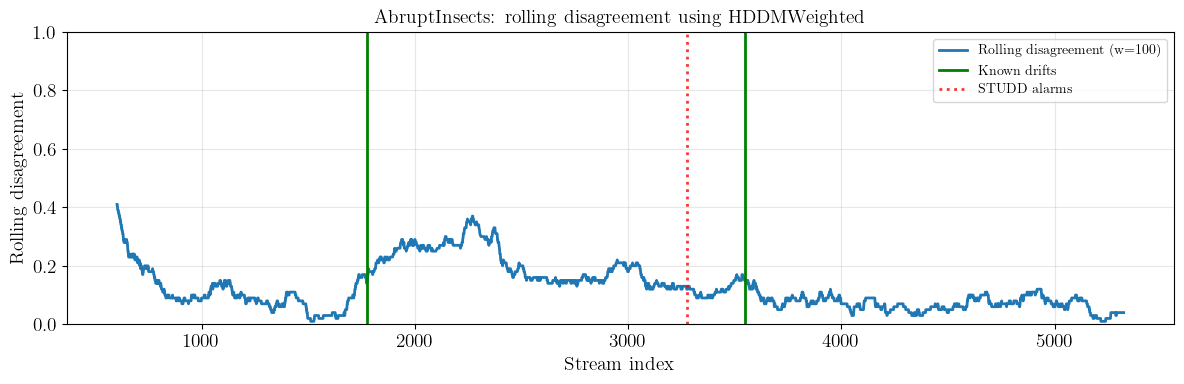

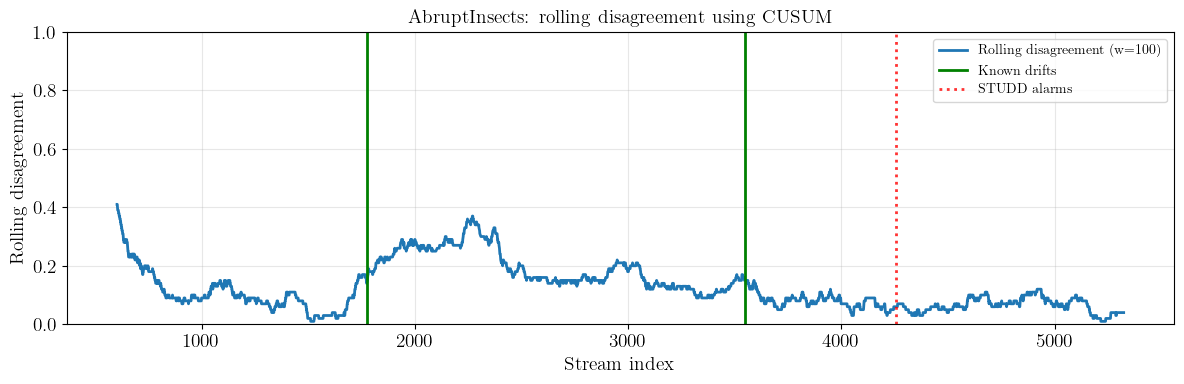

In [20]:
for detector_name, run in comparison_runs.items():

    results = run["results"]
    alarms = run["studd_drift_points"]

    valid_results = results.dropna(subset=["disagreement"])

    rolling_disagreement, _ = rolling_mean(
        valid_results["disagreement"].to_numpy(dtype=float),
        ROLLING_WINDOW,
    )

    rolling_t = valid_results["t"].to_numpy()[
        ROLLING_WINDOW - 1:
    ]

    plt.figure(figsize=(12, 4))

    plt.plot(
        rolling_t,
        rolling_disagreement,
        linewidth=2,
        label=f"Rolling disagreement (w={ROLLING_WINDOW})",
    )

    for i, drift_pos in enumerate(DRIFT_POINTS):
        plt.axvline(
            drift_pos,
            color="green",
            linewidth=2,
            label="Known drifts" if i == 0 else None,
        )

    for i, alarm in enumerate(alarms):
        plt.axvline(
            alarm,
            color="red",
            linestyle=":",
            linewidth=2,
            alpha=0.8,
            label="STUDD alarms" if i == 0 else None,
        )

    plt.title(f"AbruptInsects: rolling disagreement using {detector_name}")
    plt.xlabel("Stream index")
    plt.ylabel("Rolling disagreement")
    plt.ylim(0, 1)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Interpretation

This notebook evaluates whether STUDD alarms align with the known abrupt drift points in AbruptInsects.

The alarm matching follows a rule inspired by the STUDD paper:

If an alarm occurs before a drift and is at most `MATCH_WINDOW` observations away from that drift, it is treated as an early detection of that drift.

Otherwise, if an alarm occurs after a drift and not close enough to the next drift to be considered an early detection, it is treated as a delayed detection of the previous drift.

Very early alarms that cannot be associated with any drift remain unmatched.

The key quantities are:

- matched drift : the drift assigned to each alarm
- detection delay : negative values indicate early detection, positive values indicate delayed detection
- disagreement delta alarm : change in teacher-student disagreement around the detected alarm
- disagreement delta drift : change in teacher-student disagreement around the known drift point